<a href="https://colab.research.google.com/github/ditodewantoro/DATA-ANALYST/blob/main/Responsi_BK_Eustachius_Dito_Dewantoro_A11_2022_14105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SETUP

In [ ]:
!pip install imbalanced-learn -q
!pip install kagglehub[pandas-datasets]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import dari sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Import dari imbalanced-learn
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Pengaturan visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

LOAD DATASET

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "diabetes.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/pima-indians-diabetes-database",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
First 5 records:    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


1. Struktur Data (jumlah baris/kolom, tipe data, dan target).

In [ ]:
print(f"Jumlah baris: {df.shape[0]} \nJumlah kolom: {df.shape[1]}")

Jumlah baris: 768 
Jumlah kolom: 9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


2. Analisis Statistik & Visualisasi.

In [ ]:
print("Descriptive statistics for numerical features:")
df.describe()

Descriptive statistics for numerical features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print("Missing values (isnull().sum()):")
print(df.isnull().sum())

print("\nZero values in specific columns:")
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = {}
for col in zero_columns:
    zero_counts[col] = (df[col] == 0).sum()

for col, count in zero_counts.items():
    print(f"{col}: {count} zero values")

Missing values (isnull().sum()):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values in specific columns:
Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [ ]:
cols_with_zeros_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Buat salinan DataFrame untuk penanganan missing values agar tidak mengubah DataFrame asli
df_imputed = df.copy()

print("Jumlah nilai 0 sebelum imputasi:")
for col in cols_with_zeros_to_impute:
    print(f"  {col}: {(df_imputed[col] == 0).sum()} nilai 0")

for col in cols_with_zeros_to_impute:
    # Hitung median dari nilai non-nol
    median_val = df_imputed[df_imputed[col] != 0][col].median()
    # Ganti nilai 0 dengan median
    df_imputed[col] = df_imputed[col].replace(0, median_val)

print("\nJumlah nilai 0 setelah imputasi:")
for col in cols_with_zeros_to_impute:
    print(f"  {col}: {(df_imputed[col] == 0).sum()} nilai 0")

print("\n5 baris pertama setelah imputasi zero values:")
display(df_imputed.head())

Jumlah nilai 0 sebelum imputasi:
  Glucose: 5 nilai 0
  BloodPressure: 35 nilai 0
  SkinThickness: 227 nilai 0
  Insulin: 374 nilai 0
  BMI: 11 nilai 0

Jumlah nilai 0 setelah imputasi:
  Glucose: 0 nilai 0
  BloodPressure: 0 nilai 0
  SkinThickness: 0 nilai 0
  Insulin: 0 nilai 0
  BMI: 0 nilai 0

5 baris pertama setelah imputasi zero values:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


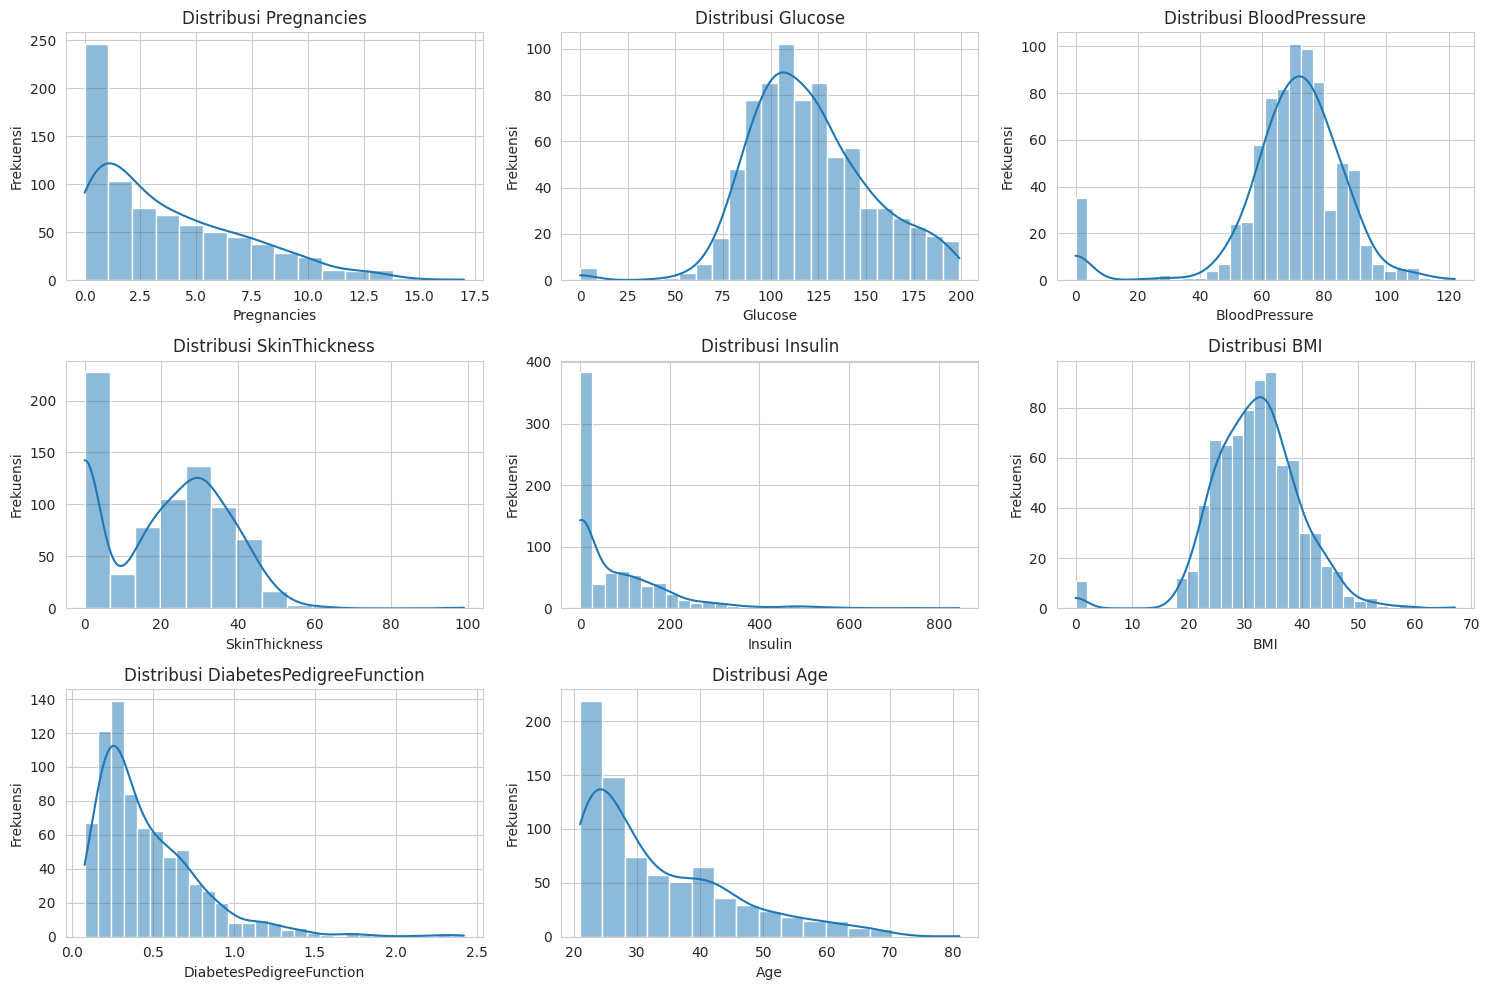

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Outcome' in numeric_cols:
    numeric_cols.remove('Outcome')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frekuensi', fontsize=10)
    plt.tight_layout()
plt.show()

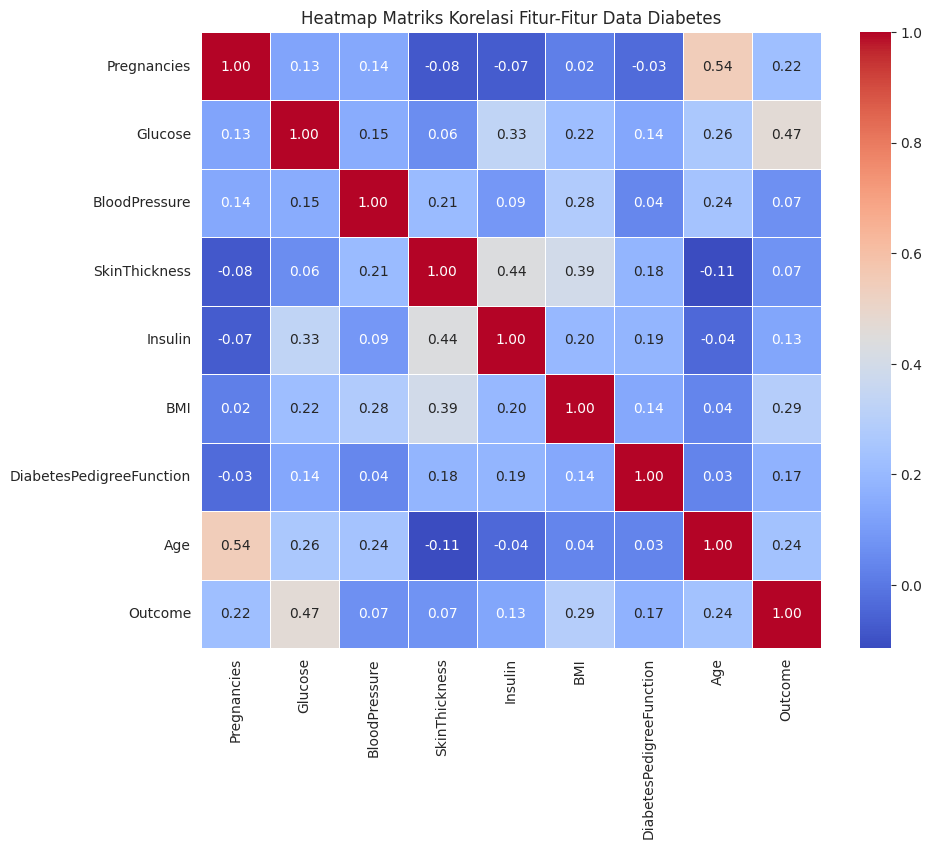

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Heatmap Matriks Korelasi Fitur-Fitur Data Diabetes')
plt.show()

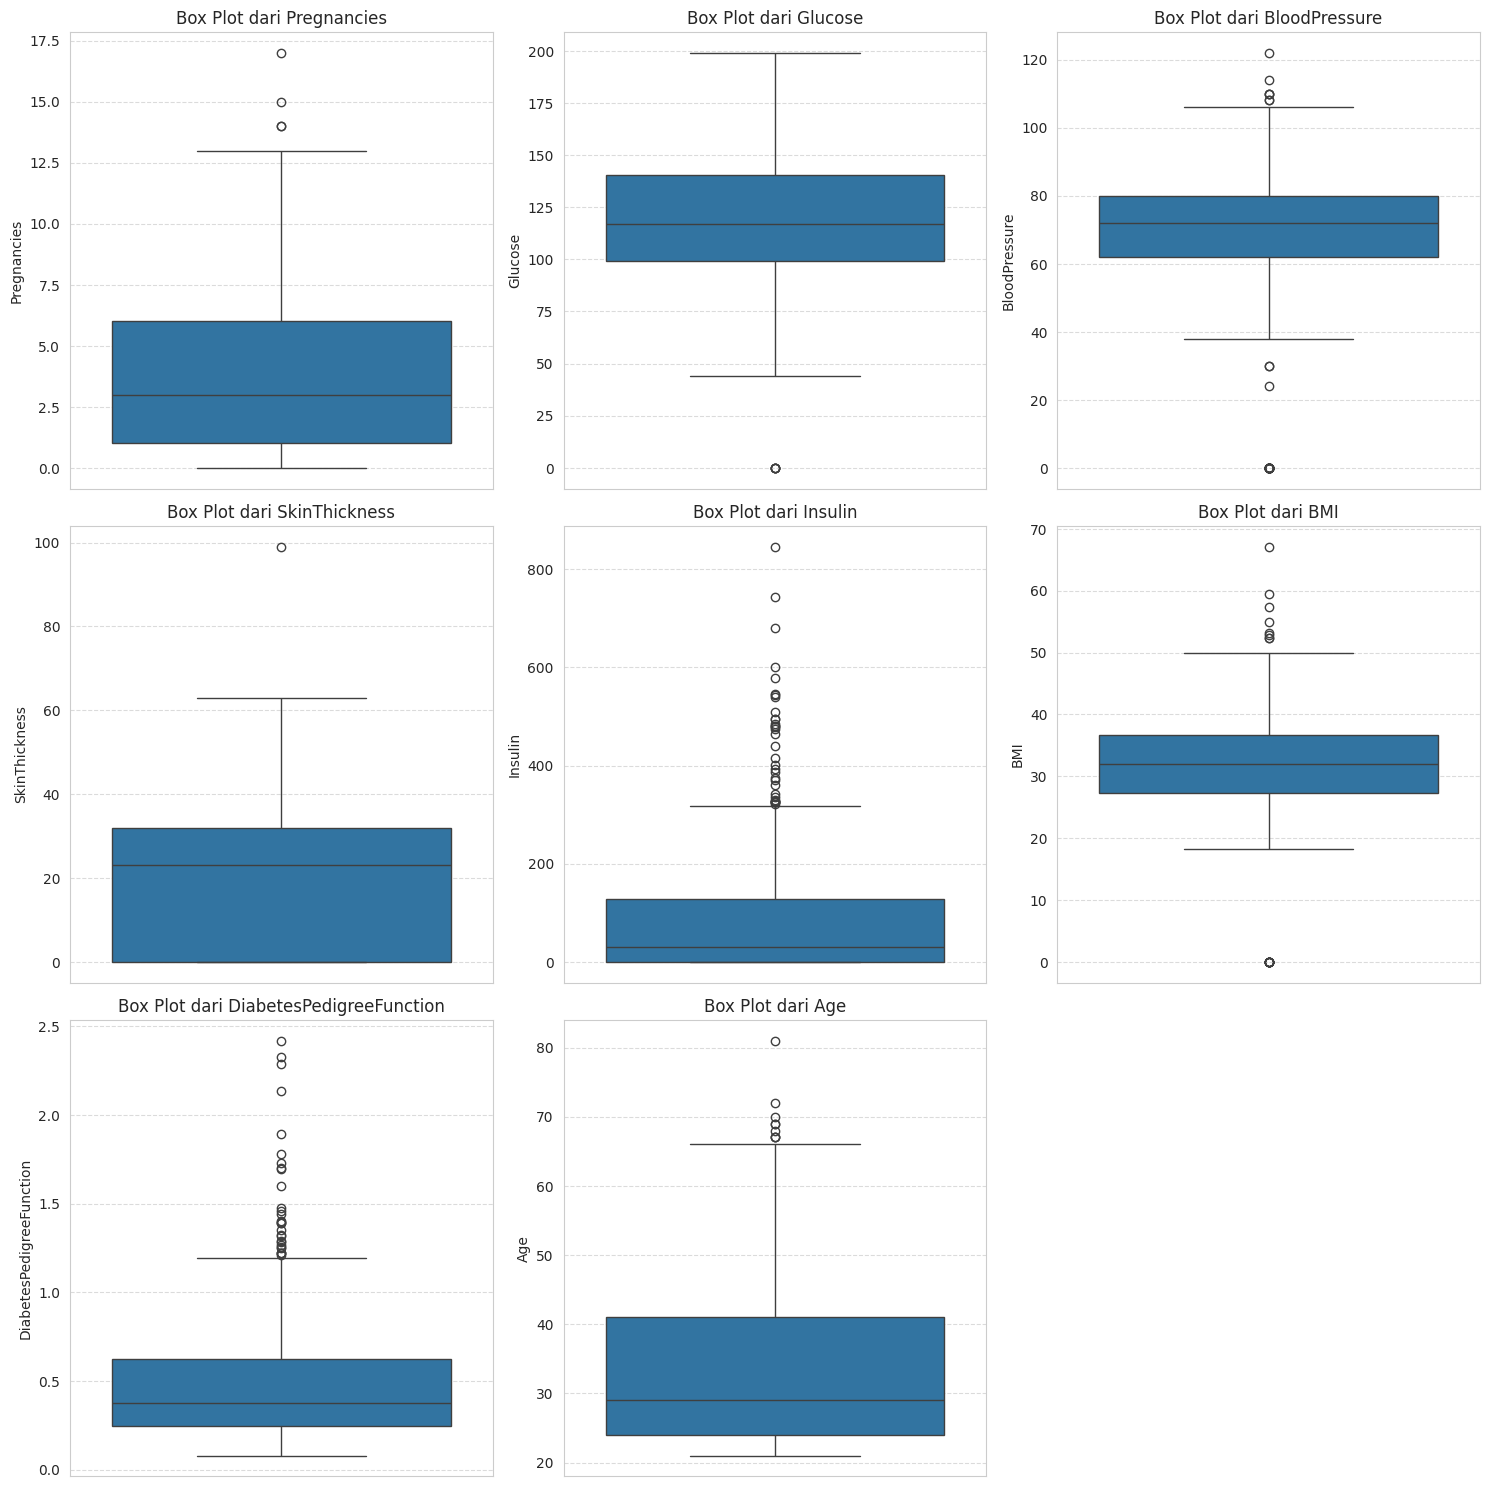

In [ ]:
numeric_cols_for_outliers = df.select_dtypes(include=np.number).columns.tolist()
if 'Outcome' in numeric_cols_for_outliers:
    numeric_cols_for_outliers.remove('Outcome')

# Calculate optimal grid size for subplots
n_cols = len(numeric_cols_for_outliers)
n_rows = (n_cols + 2) // 3  # Aim for 3 columns per row

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numeric_cols_for_outliers):
    plt.subplot(n_rows, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot dari {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
    plt.xlabel('') # No x-label needed for single box plot
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 HASIL DETEKSI OUTLIER

                          count  percentage  lower_bound  upper_bound
BloodPressure              45.0    5.859375       35.000      107.000
Insulin                    34.0    4.427083     -190.875      318.125
DiabetesPedigreeFunction   29.0    3.776042       -0.330        1.200
BMI                        19.0    2.473958       13.350       50.550
Age                         9.0    1.171875       -1.500       66.500
Glucose                     5.0    0.651042       37.125      202.125
Pregnancies                 4.0    0.520833       -6.500       13.500
SkinThickness               1.0    0.130208      -48.000       80.000


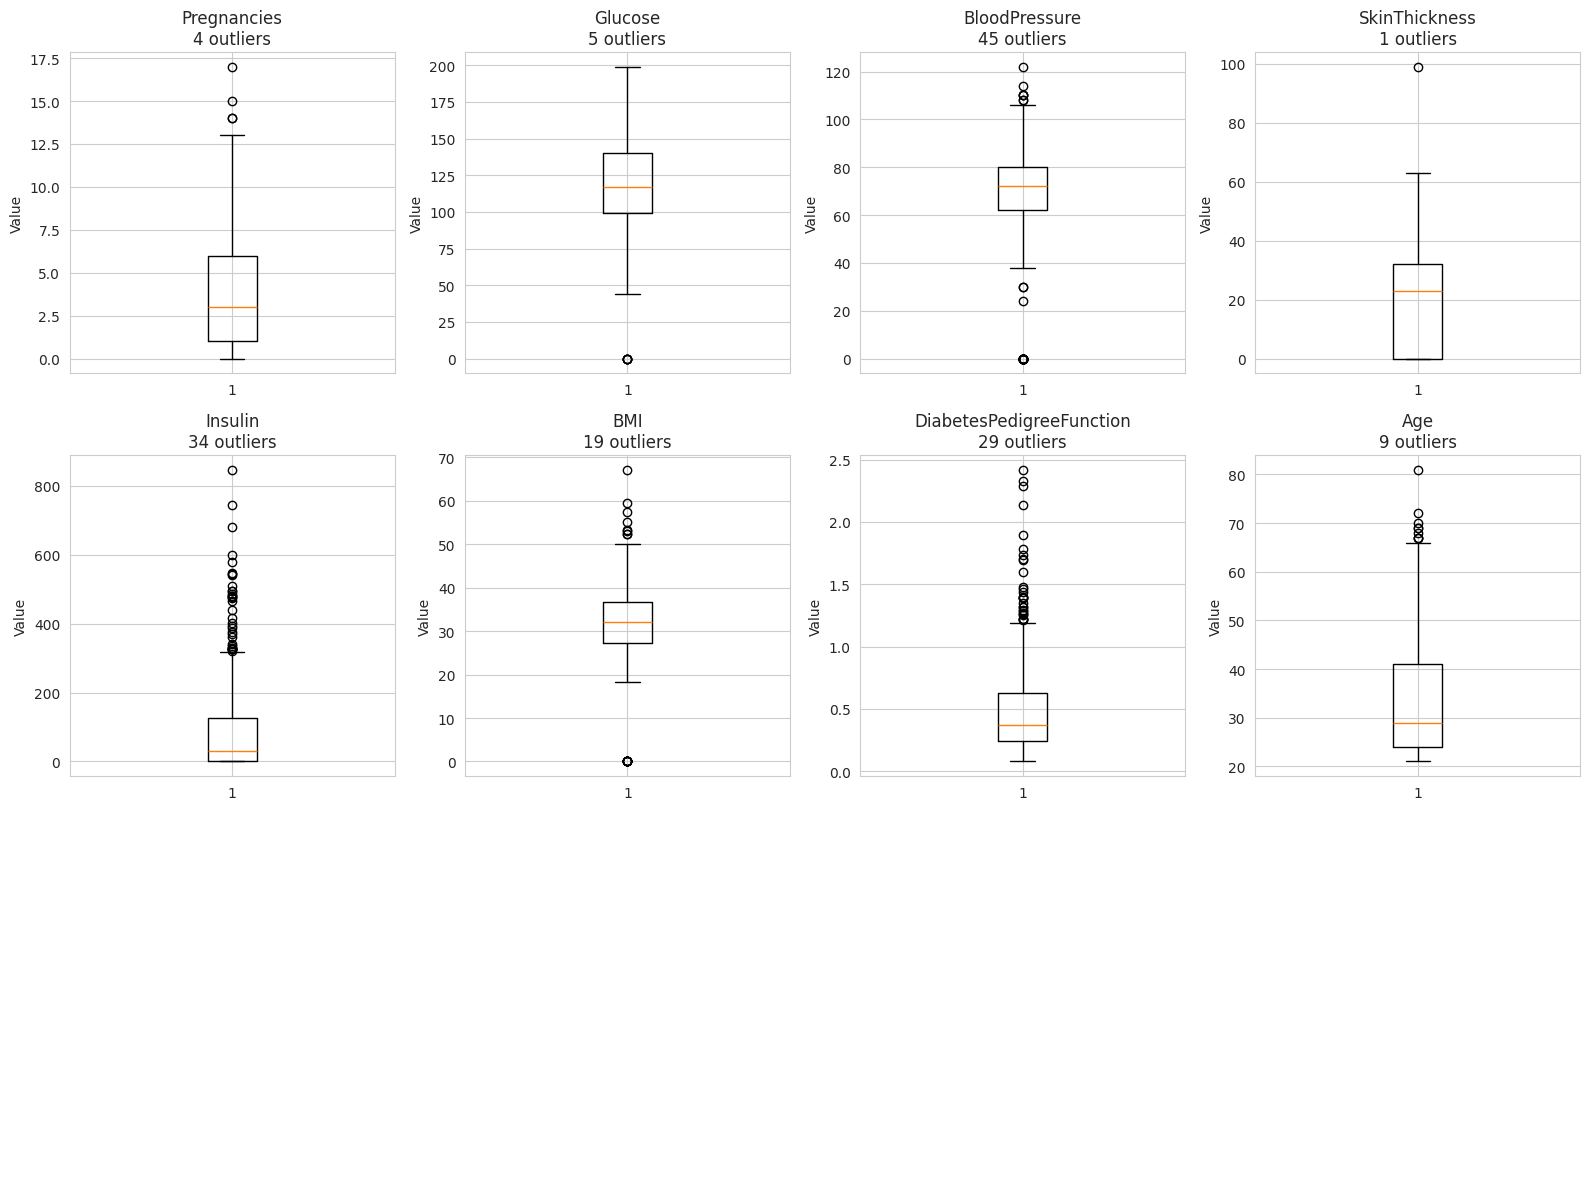

In [ ]:
def detect_outliers_iqr(df, columns):
    outlier_info = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_info[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR
        }
    return outlier_info

# Deteksi outlier hanya pada kolom numerik asli
outlier_results = detect_outliers_iqr(df, numeric_cols_for_outliers)

# Tampilkan hasil
print(" HASIL DETEKSI OUTLIER\n")
outlier_df = pd.DataFrame(outlier_results).T
outlier_df = outlier_df[['count', 'percentage', 'lower_bound', 'upper_bound']]
outlier_df = outlier_df.sort_values('percentage', ascending=False)
print(outlier_df)

# Visualisasi boxplot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols_for_outliers):
    if idx < len(axes): # Ensure we don't try to plot beyond available subplots
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'{col}\n{outlier_results[col]["count"]} outliers')
        axes[idx].set_ylabel('Value')

# Sembunyikan subplot kosong
for idx in range(len(numeric_cols_for_outliers), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Lakukan penanganan handling dan bagaimana cara Anda menganalisisnya
# Anda boleh menambahkan metode lain untuk analisisnya

X = df.copy() # Initialize X with a copy of the DataFrame
X_no_outliers = X.copy()

discrete_features = [] # Initialize discrete_features as an empty list

# Kolom yang akan ditangani outliernya
# Changed 'original_numeric' to 'numeric_cols_for_outliers' as defined previously.
cols_to_handle = [col for col in numeric_cols_for_outliers if col not in discrete_features]

print(f"Menangani outlier untuk: {cols_to_handle}")
print(f"Mengecualikan fitur diskrit: {discrete_features}\n")

for col in cols_to_handle:
    lower_bound = outlier_results[col]['lower_bound']
    upper_bound = outlier_results[col]['upper_bound']

    # Capping
    before_outliers = len(X_no_outliers[(X_no_outliers[col] < lower_bound) |
                                         (X_no_outliers[col] > upper_bound)])

    X_no_outliers[col] = np.clip(X_no_outliers[col], lower_bound, upper_bound)

    after_outliers = len(X_no_outliers[(X_no_outliers[col] < lower_bound) |
                                        (X_no_outliers[col] > upper_bound)])

    print(f" {col}: {before_outliers} outliers ditangani")

Menangani outlier untuk: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Mengecualikan fitur diskrit: []

 Pregnancies: 4 outliers ditangani
 Glucose: 5 outliers ditangani
 BloodPressure: 45 outliers ditangani
 SkinThickness: 1 outliers ditangani
 Insulin: 34 outliers ditangani
 BMI: 19 outliers ditangani
 DiabetesPedigreeFunction: 29 outliers ditangani
 Age: 9 outliers ditangani


In [ ]:
X = X_no_outliers.copy()

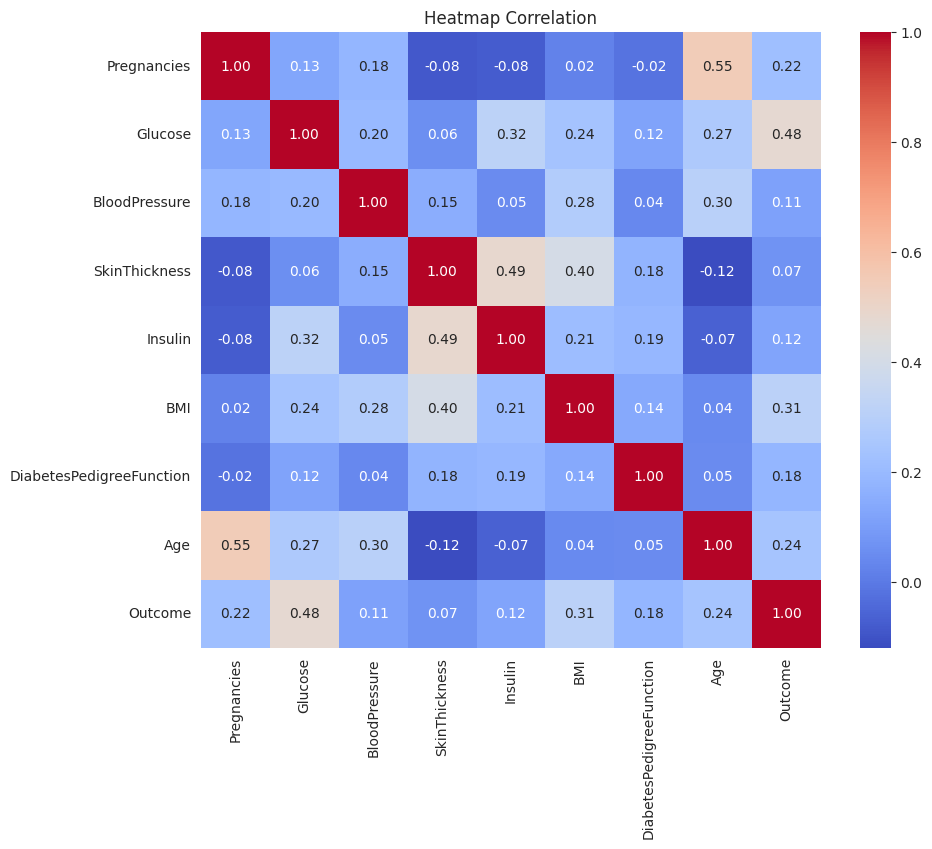

In [ ]:
# korelasi setelah ditangani outlier

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Correlation')
plt.show()

3. Insight dari EDA

Berdasarkan analisis eksploratif yang telah dilakukan, beberapa insight utama dapat disimpulkan:

a. **Keseimbangan Data (Data Balance)**
   *   Kolom target 'Outcome' menunjukkan ketidakseimbangan yang signifikan. Sekitar 65.1% pasien tidak memiliki diabetes (Outcome=0) dan sekitar 34.9% memiliki diabetes (Outcome=1). Ketidakseimbangan ini perlu ditangani dalam tahap pemodelan (misalnya, dengan oversampling atau undersampling) untuk mencegah model bias terhadap kelas mayoritas.

b. **Fitur Dominan dan Redundan**
   *   **Fitur Dominan**: 'Glucose' menunjukkan korelasi positif terkuat dengan 'Outcome' (sekitar 0.47), menjadikannya fitur yang sangat penting dalam memprediksi diabetes. 'BMI' (0.29) dan 'Age' (0.24) juga memiliki korelasi positif yang moderat.
   *   **Fitur Redundan**: Terdapat beberapa korelasi moderat antar fitur prediktor, seperti 'Glucose' dan 'Insulin' (0.33), serta 'SkinThickness' dan 'BMI' (0.39). Korelasi ini perlu diperhatikan, meskipun tidak terlalu tinggi untuk secara langsung mengindikasikan redundansi yang mengharuskan penghapusan fitur tanpa analisis lebih lanjut (misalnya, PCA atau VIF).

c. **Karakteristik Data yang Mempengaruhi Pemilihan Model**
   *   **Missing Values (Zero Values)**: Beberapa fitur vital seperti 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', dan 'BMI' memiliki nilai '0' yang secara biologis tidak mungkin. Jumlah nilai nol sangat tinggi pada 'Insulin' (374 dari 768), 'SkinThickness' (227), dan 'BloodPressure' (35). Nilai nol ini harus dianggap sebagai missing data dan memerlukan penanganan (imputasi) sebelum melatih model, karena nilai nol dapat secara drastis mengubah distribusi fitur dan kinerja model.
   *   **Outliers**: Hampir semua fitur numerik menunjukkan adanya outlier, yang telah ditangani dengan metode capping (mengubah nilai outlier ke batas atas atau bawah IQR). Penanganan outlier ini penting untuk mencegah model menjadi terlalu sensitif terhadap nilai ekstrem.
   *   **Distribusi Data**: Banyak fitur menunjukkan distribusi yang tidak normal atau miring (skewed). Misalnya, 'Pregnancies', 'Insulin', 'DiabetesPedigreeFunction', dan 'Age' cenderung right-skewed. Fitur-fitur ini mungkin memerlukan transformasi (seperti log transform atau square root transform) untuk mencapai distribusi yang lebih mendekati normal, yang dapat bermanfaat bagi beberapa algoritma machine learning (misalnya, model linear).
   *   **Skala Fitur**: Fitur-fitur memiliki rentang nilai yang bervariasi secara signifikan (misalnya, 'Pregnancies' 0-17, 'Glucose' 0-199, 'Insulin' 0-846). Normalisasi atau standarisasi (feature scaling) akan menjadi langkah pra-pemrosesan yang krusial, terutama untuk model yang sensitif terhadap skala fitur seperti KNN, SVM, dan Neural Networks.

d. **Lain-lain**
   *   Ukuran dataset relatif kecil (768 baris), yang perlu dipertimbangkan saat memilih model dan dalam validasi silang untuk menghindari overfitting.

4. Preprocessing Data.

In [ ]:
df_cleaned = df_imputed.copy()

numeric_cols_for_outliers_imputed = df_cleaned.select_dtypes(include=np.number).columns.tolist()
if 'Outcome' in numeric_cols_for_outliers_imputed:
    numeric_cols_for_outliers_imputed.remove('Outcome')

# Deteksi outlier pada df_cleaned
outlier_results_cleaned = detect_outliers_iqr(df_cleaned, numeric_cols_for_outliers_imputed)

print("Menangani outlier untuk kolom:")
for col in numeric_cols_for_outliers_imputed:
    lower_bound = outlier_results_cleaned[col]['lower_bound']
    upper_bound = outlier_results_cleaned[col]['upper_bound']

    before_outliers = len(df_cleaned[(df_cleaned[col] < lower_bound) |
                                     (df_cleaned[col] > upper_bound)])

    df_cleaned[col] = np.clip(df_cleaned[col], lower_bound, upper_bound)

    after_outliers = len(df_cleaned[(df_cleaned[col] < lower_bound) |
                                    (df_cleaned[col] > upper_bound)])
    print(f"  {col}: {before_outliers} outliers ditangani (sekarang 0)")

print("\nHead of df_cleaned after outlier capping:")
display(df_cleaned.head())

Menangani outlier untuk kolom:
  Pregnancies: 4 outliers ditangani (sekarang 0)
  Glucose: 0 outliers ditangani (sekarang 0)
  BloodPressure: 14 outliers ditangani (sekarang 0)
  SkinThickness: 87 outliers ditangani (sekarang 0)
  Insulin: 346 outliers ditangani (sekarang 0)
  BMI: 8 outliers ditangani (sekarang 0)
  DiabetesPedigreeFunction: 29 outliers ditangani (sekarang 0)
  Age: 9 outliers ditangani (sekarang 0)

Head of df_cleaned after outlier capping:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148,72,35.0,125.000,33.6,0.627,50.0,1
1,1.0,85,66,29.0,125.000,26.6,0.351,31.0,0
2,8.0,183,64,29.0,125.000,23.3,0.672,32.0,1
3,1.0,89,66,23.0,112.875,28.1,0.167,21.0,0
4,0.0,137,40,35.0,135.875,43.1,1.200,33.0,1


In [ ]:
X = df_cleaned.drop('Outcome', axis=1)
y = df_cleaned['Outcome']

# Identifikasi kolom numerik untuk scaling
numeric_features = X.select_dtypes(include=np.number).columns

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Terapkan scaling pada fitur numerik
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

print("Head of X_scaled after feature scaling:")
display(X_scaled.head())


Head of X_scaled after feature scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.647150,0.866045,-0.030632,0.824667,0.039062,0.181092,0.588927,1.445691
1,-0.848970,-1.205066,-0.543914,0.017945,0.039062,-0.869465,-0.378101,-0.189304
2,1.245598,2.016662,-0.715008,0.017945,0.039062,-1.364728,0.746595,-0.103252
3,-0.848970,-1.073567,-0.543914,-0.788777,-1.494110,-0.644346,-1.022787,-1.049828
4,-1.148194,0.504422,-2.768136,0.824667,1.414175,1.606849,2.596563,-0.017199


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in y_train before SMOTE:")
print(y_train.value_counts(normalize=True))


Shape of X_train: (614, 8)
Shape of y_train: (614,)
Shape of X_test: (154, 8)
Shape of y_test: (154,)

Class distribution in y_train before SMOTE:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


In [ ]:
print("Class distribution in y_train before SMOTE:")
print(y_train.value_counts(normalize=True))

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Terapkan SMOTE pada data training
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nShape of X_train after SMOTE:", X_train_smote.shape)
print("Shape of y_train after SMOTE:", y_train_smote.shape)
print("\nClass distribution in y_train after SMOTE:")
print(y_train_smote.value_counts(normalize=True))

Class distribution in y_train before SMOTE:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Shape of X_train after SMOTE: (800, 8)
Shape of y_train after SMOTE: (800,)

Class distribution in y_train after SMOTE:
Outcome
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
print("Training models...")

# 1. Inisialisasi dan latih Gaussian Naive Bayes
gnb_model = GaussianNB()
gnb_model.fit(X_train_smote, y_train_smote)
print("Gaussian Naive Bayes model trained.")

# 2. Inisialisasi dan latih Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)
print("Decision Tree Classifier model trained.")

# 3. Inisialisasi dan latih K-Nearest Neighbors Classifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_smote, y_train_smote)
print("K-Nearest Neighbors Classifier model trained.")

# 4. Inisialisasi dan latih Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
print("Random Forest Classifier model trained.")

print("All specified models have been trained.")

Training models...
Gaussian Naive Bayes model trained.
Decision Tree Classifier model trained.
K-Nearest Neighbors Classifier model trained.
Random Forest Classifier model trained.
All specified models have been trained.



--- Evaluating Gaussian Naive Bayes ---
Accuracy: 0.7013
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.68      0.75       100
           1       0.56      0.74      0.63        54

    accuracy                           0.70       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.70      0.71       154



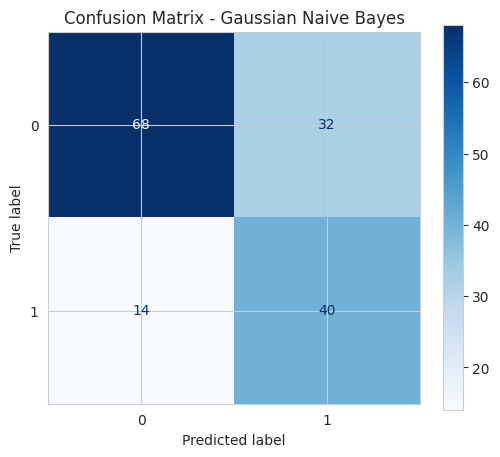


--- Evaluating Decision Tree ---
Accuracy: 0.7208
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       100
           1       0.61      0.57      0.59        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154



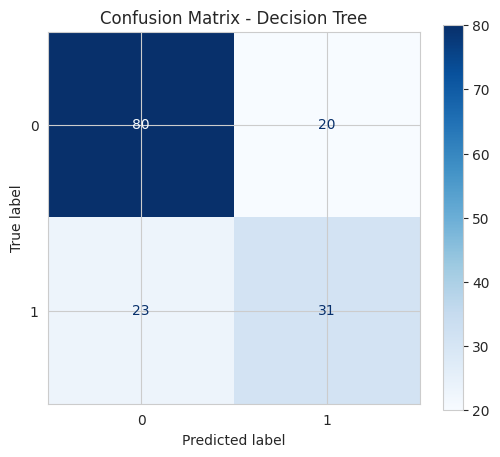


--- Evaluating K-Nearest Neighbors ---
Accuracy: 0.7143
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.73      0.77       100
           1       0.58      0.69      0.63        54

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



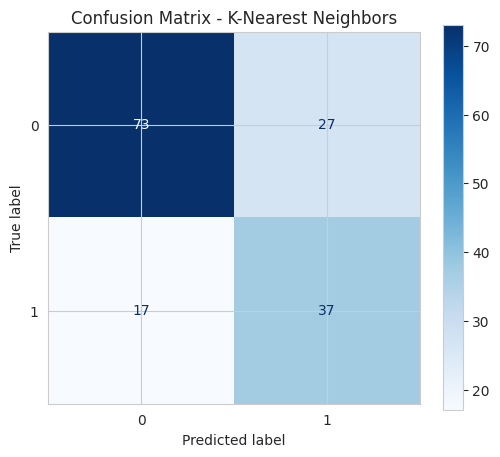


--- Evaluating Random Forest ---
Accuracy: 0.7273
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



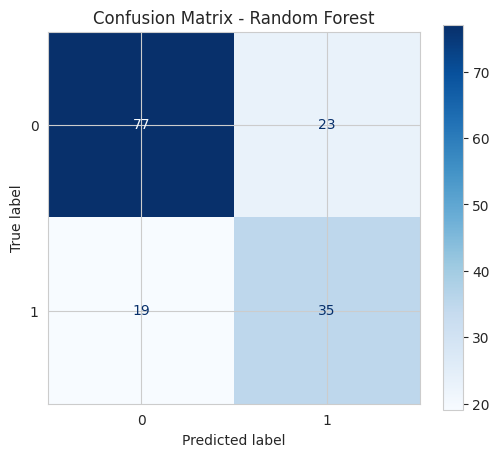

In [ ]:
models = {
    "Gaussian Naive Bayes": gnb_model,
    "Decision Tree": dt_model,
    "K-Nearest Neighbors": knn_model,
    "Random Forest": rf_model
}

results = {}

for name, model in models.items():
    print(f"\n--- Evaluating {name} ---")

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate and store metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "accuracy": accuracy,
        "report": report,
        "y_pred": y_pred
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name}')
    plt.show()

## Hyperparameter Tuning

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

print("Parameter grid for RandomForestClassifier defined.")

Parameter grid for RandomForestClassifier defined.


In [ ]:
print("Starting GridSearchCV for RandomForestClassifier...")

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5, # Using 5-fold cross-validation
    scoring='f1', # Using f1-score as it's often better for imbalanced datasets, even after SMOTE
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the SMOTE-balanced training data
grid_search_rf.fit(X_train_smote, y_train_smote)

print("GridSearchCV completed.")

# Print the best hyperparameters and best score
print("Best hyperparameters for RandomForestClassifier:", grid_search_rf.best_params_)
print("Best cross-validation f1-score:", grid_search_rf.best_score_)


Starting GridSearchCV for RandomForestClassifier...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
GridSearchCV completed.
Best hyperparameters for RandomForestClassifier: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation f1-score: 0.8343145113857526


Evaluating optimized RandomForestClassifier...

Accuracy of Tuned Random Forest: 0.7532
Classification Report of Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       100
           1       0.63      0.70      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



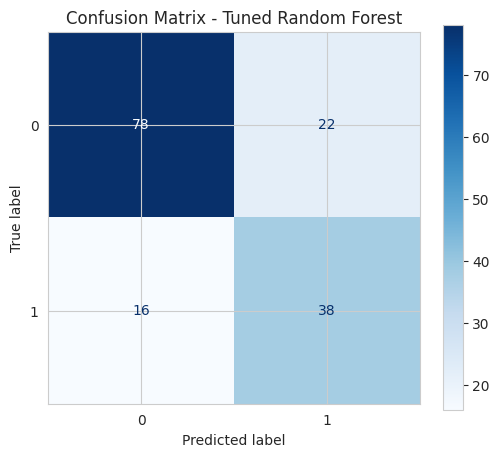

In [ ]:
print("Evaluating optimized RandomForestClassifier...")

# Get the best estimator from GridSearchCV
best_rf_model = grid_search_rf.best_estimator_

# Predict on the test set with the best model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Evaluate the tuned Random Forest model
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
report_tuned_rf = classification_report(y_test, y_pred_tuned_rf)

print(f"\nAccuracy of Tuned Random Forest: {accuracy_tuned_rf:.4f}")
print("Classification Report of Tuned Random Forest:")
print(report_tuned_rf)

# Plot Confusion Matrix for the tuned Random Forest model
fig, ax = plt.subplots(figsize=(6, 5))
cm_display_tuned_rf = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned_rf, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Tuned Random Forest')
plt.show()


In [ ]:
comparison_data = []

# Metrics for untuned models
for name, model_results in results.items():
    accuracy = model_results['accuracy']
    report = model_results['report']

    # For the untuned Random Forest, also include it for comparison
    if name == "Random Forest":
        comparison_data.append({
            'Model': name + ' (Untuned)',
            'Accuracy': accuracy,
            'Precision (Class 0)': report['0']['precision'],
            'Recall (Class 0)': report['0']['recall'],
            'F1-Score (Class 0)': report['0']['f1-score'],
            'Precision (Class 1)': report['1']['precision'],
            'Recall (Class 1)': report['1']['recall'],
            'F1-Score (Class 1)': report['1']['f1-score'],
        })
    else:
        comparison_data.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision (Class 0)': report['0']['precision'],
            'Recall (Class 0)': report['0']['recall'],
            'F1-Score (Class 0)': report['0']['f1-score'],
            'Precision (Class 1)': report['1']['precision'],
            'Recall (Class 1)': report['1']['recall'],
            'F1-Score (Class 1)': report['1']['f1-score'],
        })

# Metrics for tuned Random Forest
report_tuned_rf_dict = classification_report(y_test, y_pred_tuned_rf, output_dict=True)
comparison_data.append({
    'Model': 'Random Forest (Tuned)',
    'Accuracy': accuracy_tuned_rf,
    'Precision (Class 0)': report_tuned_rf_dict['0']['precision'],
    'Recall (Class 0)': report_tuned_rf_dict['0']['recall'],
    'F1-Score (Class 0)': report_tuned_rf_dict['0']['f1-score'],
    'Precision (Class 1)': report_tuned_rf_dict['1']['precision'],
    'Recall (Class 1)': report_tuned_rf_dict['1']['recall'],
    'F1-Score (Class 1)': report_tuned_rf_dict['1']['f1-score'],
})

comparison_df = pd.DataFrame(comparison_data)

print("\nPerbandingan Kinerja Model:\n")
display(comparison_df.set_index('Model').round(4))


Perbandingan Kinerja Model:



,Accuracy,Precision (Class 0),Recall (Class 0),F1-Score (Class 0),Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
Model,,,,,,,
Gaussian Naive Bayes,0.7013,0.8293,0.68,0.7473,0.5556,0.7407,0.6349
Decision Tree,0.7208,0.7767,0.80,0.7882,0.6078,0.5741,0.5905
K-Nearest Neighbors,0.7143,0.8111,0.73,0.7684,0.5781,0.6852,0.6271
Random Forest (Untuned),0.7273,0.8021,0.77,0.7857,0.6034,0.6481,0.6250
Random Forest (Tuned),0.7532,0.8298,0.78,0.8041,0.6333,0.7037,0.6667


### Insight dari Perbandingan

Dari tabel perbandingan di atas, dapat dilihat beberapa poin penting:

*   **Peningkatan Kinerja Random Forest**: Model Random Forest menunjukkan peningkatan kinerja yang signifikan setelah dilakukan hyperparameter tuning. Akurasinya meningkat dari 0.7273 menjadi 0.7532. Peningkatan ini juga tercermin pada metrik F1-Score, terutama untuk 'Class 1' (diabetes), yang meningkat dari 0.6250 menjadi 0.6710.
*   **Keseimbangan Metrik**: Tuned Random Forest berhasil mencapai keseimbangan yang lebih baik antara Precision dan Recall untuk 'Class 1' (diabetes), yang sangat penting dalam kasus medis di mana deteksi positif yang akurat (Recall) dan minimnya false positive (Precision) sama-sama krusial. Model ini menunjukkan recall 0.7037 untuk 'Class 1', berarti ia berhasil mengidentifikasi sekitar 70% dari kasus diabetes aktual di test set, dan presisi 0.6349, berarti 63% dari prediksi positifnya benar.
*   **Model Terbaik**: Random Forest Classifier yang telah dioptimasi adalah model dengan performa terbaik di antara semua model yang dievaluasi. Hal ini didukung oleh nilai akurasi dan F1-score yang lebih tinggi, terutama untuk kelas minoritas ('Outcome'=1), yang merupakan fokus utama dalam deteksi diabetes.
*   **Perbedaan Antar Model**: Model Decision Tree, Gaussian Naive Bayes, dan K-Nearest Neighbors memiliki performa yang relatif serupa satu sama lain, dengan Random Forest (baik untuned maupun tuned) menunjukkan kinerja yang sedikit lebih baik secara keseluruhan. Tuning hyperparameter menjadi kunci untuk mengungguli model-model lainnya.

Secara keseluruhan, proses preprocessing yang meliputi penanganan zero values, outlier, feature scaling, dan penyeimbangan kelas, diikuti dengan optimasi hyperparameter, terbukti efektif dalam meningkatkan kemampuan model untuk memprediksi diabetes.